<h1 align="center">LNR_LAB_6: Transformers and Explainability</h2>
<h3 style="display:block; margin-top:5px;" align="center">Natural Language and Information Retrieval</h3>
<h3 style="display:block; margin-top:5px;" align="center">Degree in Data Science</h3>
<h3 style="display:block; margin-top:5px;" align="center">ETSInf. Universitat Politècnica de València</h3>
<br>

### Put your names here

- (replace with one name)
- (replace with another name)

In [ ]:
!pip install jupyter --upgrade
!pip install ipywidgets --upgrade

### CONSTANTS

In [ ]:
COLAB = True # IF YOU USE GOOGLE COLAB -> COLAB = True
PIP = True # IF YOU NEED INSTALL LIBRARIES -> PIP = True

**If you have trouble installing ferret-xai or jsonnet on Linux, try installing these packages first:**

- sudo apt install cmake   
- sudo apt install g++     
- sudo apt install make

**Or that after installing ferret-xai:**

- conda install -c conda-forge libstdcxx-ng --update-deps


## Some libraries

In [ ]:
#!pip install "setuptools<82"
#!pip install torch
#!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.8 MB/s  0:00:00


In [ ]:
#!pip install numpy --upgrade --no-input
#!pip install ferret-xai --upgrade --no-input
# SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True
#!pip install ferret-xai


In [ ]:
SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True
if PIP:
    !pip install numpy --upgrade --no-input
    !pip install transformers --upgrade --no-input
    !pip install datasets accelerate --upgrade --no-input
    !pip install ferret-xai --upgrade --no-input
    !pip install tqdm --no-input
    !pip install scikit-learn --upgrade --no-input

In [ ]:
import os
import sys
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from typing import List, Tuple
#from datasets import Dataset
import tqdm

In [ ]:
if COLAB is True:
  from google.colab import drive
  drive.mount('/content/drive')
  base_path = "/content/drive/MyDrive/LNR/"
else:
  base_path = "../"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Read the dataset

In [ ]:
# Load the development sets for subtask 2.1 and subtask 2.2 and for each language. The same development sets used in previous labs.




In [ ]:
SpDevTask2.head()

,id,text,label_22
0,111712,LAS RUBIAS NO SOMOS TONTAS Valves SABEMOS CONTAR,DIRECT
1,111778,-¿Sabes chiflar? -Solo con los dedos en los la...,DIRECT
2,111670,f Señor Darcy de Pemberley He luchado contra m...,JUDGEMENTAL
3,111034,UNA MUJER PUEDE SER LA MAS DULCE DEL CIELO O L...,DIRECT
4,110266,Otros Mangakas: AT Boku no Memes Academia Ofic...,DIRECT


## Dataset class

In [ ]:
class SexismDataset(Dataset):
    def __init__(self, texts, labels, ids, tokenizer, max_len=128, pad="max_length", trunc=True,rt='pt'):
        self.texts = texts.tolist()
        self.labels = labels
        self.ids = ids
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.pad = pad
        self.trunc = trunc
        self.rt = rt

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        inputs = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,padding=self.pad, truncation=self.trunc,
            return_tensors=self.rt
        )

        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long),
            'id': torch.tensor(self.ids[idx], dtype=torch.long)
        }

## Auxiliary functions

In [ ]:
from collections import Counter # Counter counts the number of occurrences of each item
from itertools import tee, count

def uniquify(seq, suffs = count(1)):
    """Make all the items unique by adding a suffix (1, 2, etc).

    `seq` is mutable sequence of strings.
    `suffs` is an optional alternative suffix iterable.
    """
    not_unique = [k for k,v in Counter(seq).items() if v > 1] # so we have: ['name', 'zip']
    # suffix generator dict - e.g., {'name': <my_gen>, 'zip': <my_gen>}
    suff_gens = dict(zip(not_unique, tee(suffs, len(not_unique))))
    for idx,s in enumerate(seq):
        try:
            suffix = str(next(suff_gens[s]))
        except KeyError:
            # s was unique
            continue
        else:
            seq[idx] += suffix

def deduplicate(explanations):
    for i in range(len(explanations)):
        tokens = explanations[i].tokens
        uniquify(tokens, (f'_{x!s}' for x in range(1, 100)))
        explanations[i].tokens=tokens
    return explanations

In [ ]:
#Select the device to run the model on (GPU if available, otherwise CPU)
device = "cpu"
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")

# Two options to predict

### The simplest

In [ ]:
def predict_op1(model, dataset, args = {}):

    # Set up the Trainer, yes, a trainer for prediction!
    training_args = TrainingArguments(
        output_dir="./output",
        per_device_eval_batch_size = args.get("per_device_eval_batch_size", 16),
        do_train=False,
        do_eval=False,
    )
    trainer = Trainer(model=model, args=training_args)

    # Predict
    predictions = trainer.predict(dataset)

    # Get logits, shape = #samples, num_classes (2)
    logits = predictions.predictions

    # Compute probability with softmax, requires logits to be tensors (unnecessary to compute the class)
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()
    probs2 = np.max(probs, axis=-1)

    # Get the predicted class using argmax
    pred_classes = np.argmax(logits, axis=-1)
    # equals to: pred_classes = np.argmax(probs, axis=-1)

    return pred_classes, probs2

### The coolest, if you know what you're doing

In [ ]:
def predict_op2(model, dataset, args = {}):
    # batch_size
    batch_size = args.get("per_device_eval_batch_size", 16)

    model.to(device)
    # Set eval model, no gradient stored
    model.eval()

    # Prepare DataLoader
    dataloader = DataLoader(dataset, batch_size=batch_size)

    # Prediction loop
    logits_list = []
    with torch.no_grad():
        for batch in tqdm.notebook.tqdm(dataloader):
            del batch["id"]
            batch = {k: v.to(device) for k, v in batch.items()}
            # equals to: outputs = model.forward(**batch)
            outputs = model(**batch)
            logits_list.append(outputs.logits)

    # Concatenate and move logits to the CPU, shape = #samples, num_classes (2)
    logits = torch.cat(logits_list, dim=0).cpu()

    # Compute probability with softmax, requires logits to be tensors (unnecessary to compute the class)
    probs = torch.nn.functional.softmax(logits, dim=-1).numpy()
    probs2 = np.max(probs, axis=-1)

    # Get the predicted class using argmax
    pred_classes = np.argmax(logits, axis=-1).numpy()
    # equals to: pred_classes = np.argmax(probs, axis=-1).numpy()


    return pred_classes, probs2


### Predictions from the best English model

In [ ]:
model_name = "EXIST/final_best_model_task1_eng"
base_model = "roberta-base"
#model_name = "best_models_subtask1/spanish"
#base_model = "pysentimiento/robertuito-base-deacc"


tokenizer = AutoTokenizer.from_pretrained(base_model)
model = AutoModelForSequenceClassification.from_pretrained(os.path.join(base_path, model_name))#,        num_labels=nlabels,        problem_type=ptype )

val_dataset = SexismDataset(EnDevTask1['text'], LabelEncoder().fit_transform(EnDevTask1['label_21']), [int(x) for x in EnDevTask1['id']], tokenizer)

#preds = predict_op1(model, val_dataset)
preds, probs = predict_op1(model, val_dataset)

# If you want to verify that both options do the same , try this:
y_pred1, probs1 = predict_op1(model, val_dataset)
y_pred2, probs2 = predict_op2(model, val_dataset)
all(x1 == x2 for x1, x2 in zip(y_pred1, y_pred2))

  0%|          | 0/22 [00:00<?, ?it/s]

True

### Evaluation of the results

In [ ]:
def compute_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary'
    )
    acc = accuracy_score(y_true, y_pred)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
    }

# Metrics
metrics = compute_metrics(val_dataset.labels, preds)
print("Metrics:", metrics)

# Confusion matrix
conf_matrix = confusion_matrix(val_dataset.labels, preds)#, labels=["NO", "YES"])
print("\nConfusion matrix:")
print(conf_matrix)

# Classification report
class_report = classification_report(val_dataset.labels, preds, target_names=["NO", "YES"], digits=4)
print("\nReport:")
print(class_report)

Metrics: {'accuracy': 0.7067448680351907, 'f1': 0.7863247863247863, 'precision': 0.7049808429118773, 'recall': 0.8888888888888888}

Confusion matrix:
[[ 57  77]
 [ 23 184]]

Report:
              precision    recall  f1-score   support

          NO     0.7125    0.4254    0.5327       134
         YES     0.7050    0.8889    0.7863       207

    accuracy                         0.7067       341
   macro avg     0.7087    0.6571    0.6595       341
weighted avg     0.7079    0.7067    0.6867       341



### Plot confusion matrix


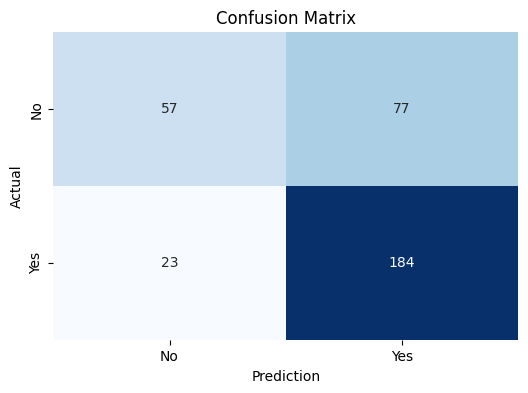

In [ ]:
#!pip install matplotlib seaborn --upgrade
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No", "Yes"],
            yticklabels=["No", "Yes"])
plt.title("Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

### Text and probability of False positive and False negative

In [ ]:
def false_positive_false_negative(
    y_true: List[int], y_pred: List[int], pred_probs: List[float], texts: List[str]
) -> Tuple[List[Tuple[float, str]], List[Tuple[float, str]]]:
    """
    returns incorrect predictions from a binary classification model.

    Parameters:
    - y_true (list[int]): True labels for each sample (0 or 1).
    - y_pred (list[int]): Labels predicted by the model (0 or 1).
    - pred_probs (list[float]): Probabilities assigned by the model to the predicted class.
    - texts (list[str]): Text of each sample.

    Returns:
    - false_positives (list[tuple[float, str]]): List of tuples for false positives.
    - false_negatives (list[tuple[float, str]]): List of tuples for false negatives.
    Each tuple of both lists includes the probability and the text of the sample.
    """



    return false_positive, false_negative

In [ ]:
fpositive, fnegative = false_positive_false_negative(y_true = val_dataset.labels, y_pred = preds, pred_probs = probs, texts = val_dataset.texts)

print("False positive:", len(fpositive))
for s in fpositive:
    print('**', s)

print("\n\nFalse negative:", len(fnegative))
for s in fnegative:
    print('**', s)

False positive: 77
** (0.9972034692764282, 'OMG A BEAUTIFUL GIRL I WILL KILL MYSELF  ')
** (0.9971107244491577, "I WARNED HER NOT TO EAT THE CHILI NOW SHE'S CLINCHING HER CHEEKS imgflip.com  ")
** (0.9968980550765991, "TODAYS INTERNATIONAL WOMEN'S DAY!! DAT OK CAUSE IT BE INTERNATIONAL MEN'S DAY EVERY OTHER DAY imgflip.com  ")
** (0.996684730052948, 'When she appoints you as the guy she calls when shes horny  ')
** (0.9965298771858215, 'FIRST, I WANNA DANCE NAKED THEN I WANT TO EAT STRAWBERRIES OUT OF YOUR BUTT memeshappen.com  ')
** (0.9964126944541931, "WHEN SHE'S CRAZY BUT SHE STILL MAKES YOU EINSTEIN FACE HAPPY makeameme.org  ")
** (0.996408998966217, 'H Show me the strongest woman I said strongest Perfection  ')
** (0.9964016675949097, 'YOURE A BASIC BITCH CASE DISMISSED quickmeme.com  ')
** (0.9963843822479248, 'Pun hub My wife is going into labour what should i do? Is this her first child? @PunHubOnline No, this is her husband  ')
** (0.9963801503181458, '*after a one night stan

### Select some samples to analyze

You can select the samples with more confidence, those with less confidence, a mix of both, or simply the ones you consider more interesting.



**Try not to choose the same samples that I’ve selected, and Justify your decision**.


In [ ]:
# Make your own selection

fpositive_samples = [
    "When she appoints you as the guy she calls when shes horny  ",
    "*after a one night stand* Girl: How do you like your eggs? Guy: Alone. @rollervaper "
    ]

fnegative_samples = [
    "When you show her your Pokemon card collection: okay now i'm wet streamlabs  ",
    "Watching my husband fix himself a snack right after I cleaned the entire kitchen @NOT THENANNY  "
]

In [ ]:
# Use Ferret to analyse the selected examples

from ferret import Benchmark
from IPython.display import display_html



### Show explanations

False Positive:


Explainer:   0%|          | 0/2 [00:00<?, ?it/s]

Explanation eval:   0%|          | 0/2 [00:00<?, ?it/s]

Sentence: When she appoints you as the guy she calls when shes horny  
Class: 1


Token,When,Ġshe_1,Ġappoint,s_1,Ġyou,Ġas,Ġthe,Ġguy,Ġshe_2,Ġcalls,Ġwhen,Ġshe_3,s_2,Ġhorny,Ġ_1,Ġ_2
Partition SHAP,0.11,0.11,0.10,0.10,0.00,0.02,0.02,0.01,0.15,0.09,-0.04,0.05,0.09,0.10,-0.01,-0.01
LIME,0.06,0.15,0.07,0.02,-0.00,0.01,-0.07,0.03,0.11,-0.10,-0.07,0.16,-0.03,-0.07,0.01,-0.03


...

Explainer:   0%|          | 0/2 [00:00<?, ?it/s]

Explanation eval:   0%|          | 0/2 [00:00<?, ?it/s]

Sentence: Watching my husband fix himself a snack right after I cleaned the entire kitchen @NOT THENANNY  
Class: 0


Token,Watch,ing,Ġmy,Ġhusband,Ġfix,Ġhimself,Ġa,Ġsnack,Ġright,Ġafter,ĠI,Ġcleaned,Ġthe,Ġentire,Ġkitchen,Ġ@,NOT,ĠTHEN,AN,NY,Ġ_1,Ġ_2
Partition SHAP,0.05,0.00,0.07,0.09,-0.09,-0.02,0.08,-0.00,-0.02,0.02,0.06,-0.10,0.03,0.00,0.07,0.11,-0.08,0.07,0.02,-0.00,0.00,0.00
LIME,0.01,0.03,0.18,0.05,0.07,0.02,0.02,0.15,-0.01,0.02,0.08,-0.04,0.02,0.03,0.10,0.01,-0.07,-0.01,0.03,0.02,-0.00,-0.02


,aopc_compr,aopc_suff,taucorr_loo
Partition SHAP,0.05,0.06,0.25
LIME,0.79,-0.01,0.31


# DO IT IN SPANISH

In [ ]:
# COMPLETE